In [1]:
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
import os
from typing import Literal
from pydantic import BaseModel
from tavily import TavilyClient

from dotenv import load_dotenv

load_dotenv()


/Users/rahultiwari/Documents/02_Freelancing/coding_ninja_fresh/dummy-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
# 1 load the pdf files
pdf_loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = pdf_loader.load()

# 2 . split documents into chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = text_splitter.split_documents(raw_docs)
print(len(chunks))

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vectorstore = Chroma(
    collection_name="rag_base",
    embedding_function=embeddings,
    # persist_directory="../chroma_db". # this is optional for this run
)

vectorstore.add_documents(chunks)


51


['00ad4896-a35f-4890-a3d8-32731633aa4d',
 '88f71629-b183-4ac8-a26b-e4765af13ab0',
 '0d2dfd35-c68d-47c3-8678-95f7e41d65e5',
 'c62f9f12-6c5c-4773-b877-24ac5f00954e',
 'ab9d8699-0927-4e24-b5d1-f944c70c30dd',
 'd70dc036-7c6d-47c6-9f54-e17200d17e58',
 '2db4b4bf-0627-4b51-8121-3533cda28b80',
 'a4d1566d-c438-43f0-ac03-a0d8e4c49ae5',
 '69d36ea0-9f2c-4faf-b8c5-4580967e16eb',
 '3531172f-fd40-4674-b009-efff6ba0ab57',
 'cd349a8c-d1af-43a9-bc15-56cff7a636e6',
 'ae53b9bc-df9a-4863-8119-2e4a2b54b3dd',
 '3e7dc7b5-9411-4976-9a5b-9db495f7ff33',
 '79b7b485-cc28-478d-9769-c0f543c1ab6b',
 '1166f890-e438-4aca-96e2-108cbe9ea52e',
 'e9a7716f-01ed-40ea-9935-648077398109',
 '46a3a93a-fd13-44a7-8761-dae7a0e80678',
 '54503197-1929-4a17-aca7-c6bcd020b50f',
 '5e5a70a9-0cba-45b6-a072-2c67fd30086d',
 '5969f4c7-a3f5-4617-b11e-743695571d46',
 'f92d8447-fb68-41ee-b1fc-2e92468d2d83',
 '6f53c17a-a3cf-44f2-9394-71abd6ae5264',
 '0658b100-917e-4c79-b5d5-a2a1d5377cfd',
 'bac8538a-accf-44ff-9238-437c83d85e0f',
 '28545551-d0c7-

In [3]:
llm = ChatOpenAI(model="gpt-4o-mini") # this is for route_questions and generation
agent_llm = ChatOpenAI(model="gpt-5-mini") 

In [56]:
class AgenticRAGState(MessagesState):
    query: str
    retrieved_docs: list[Document]
    relevant_docs: list[Document]
    context: str
    generation: str
    needs_retrieval: bool
    retrieval_count: int
    max_retrieval_step: int
    is_relevant: bool
    rewritten_query: str
    rewrite_count: int


In [6]:
class RouteDecision(BaseModel):
    needs_retrieval: bool

In [7]:
class RelevanceEvaluation(BaseModel):
    is_relevant: bool

In [ ]:
@tool(response_format="content_and_artifact")
def vector_store_search(query: str, k:int = 3):
    """ 
    Search the vector store for relevant document passages.
    Adjust k (default 3) to retrieve more or fewer passages.
    
    """
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(query)
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in docs)

    return context,docs


In [9]:
import os

@tool(response_format="content_and_artifact")
def web_search(query:str, max_results:int = 3):
    """
    Search the web for relevant information.
    Adjust max_results (default 3) to retrieve more or fewer results.
    """
    client = TavilyClient(api_key=os.getenv("TVLY_API_KEY"))
    response = client.search(query, max_results=max_results)
    docs = [
        Document(
            page_content=r["content"],
            metadata={"source": r["url"], "title": r.get("title", "")},
        )
        for r in response["results"]
    ]
    content = "\n\n## Web Search Results\n\n" + "\n\n".join(d.page_content for d in docs)

    return content, docs


In [12]:
# print(web_search.invoke('tell me 5 news from India'))

In [13]:
tools = [web_search, vector_store_search]
agent_llm_with_tools = agent_llm.bind_tools(tools)
tool_node = ToolNode(tools)

In [14]:
def route_question(state: AgenticRAGState) -> dict:

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document or the web, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])

    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})

    return {"needs_retrieval": decision.needs_retrieval}

In [ ]:
# state = {
#     "query": "tell me 5 fact about India"
# }
# route_question(state)

{'needs_retrieval': False}

In [18]:
# route_question()

In [19]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools."
)

In [33]:
def agent(state: AgenticRAGState) -> dict:
    rewritten= state.get("rewritten_query")
    if rewritten:
        print('inside if block')
        messages = [SystemMessage(content=AGENT_SYSTEM_PROMPT),
                    HumanMessage(content=rewritten)]
        
    else:
        print('inside else block')
        messages = []
        if not messages:
            messages = [
                SystemMessage(content=AGENT_SYSTEM_PROMPT),
                HumanMessage(content=state["query"]),
            ]

    response = agent_llm_with_tools.invoke(messages)
    return {"messages": [response]}

In [35]:
state = {
    "query": "tell me 5 fact about India",
    "rewritten_query": "According to the report, how will the adoption of electric vehicles impact oil demand?"
}

result = agent(state)

inside if block


In [41]:
result['messages'][0].tool_calls    

[{'name': 'vector_store_search',
  'args': {'query': 'Will EVs Dampen the Oil Price Shock? report impact of electric vehicle adoption on oil demand displacement scenarios fleet turnover oil demand projections through 2050 key findings',
   'k': 6},
  'id': 'call_Y5WZo33alr5c24sAJgbCWj0f',
  'type': 'tool_call'}]

In [43]:
vector_store_search.invoke("According to the report, how will the adoption of electric vehicles impact oil demand?")

'\n\n## Vector Store Results\n\nEnergy Agency, and McKinsey collectively project that EVs will account for between 40 and\n60 percent of new vehicle sales globally by 2030. The stock of EVs on the road — which\nmatters more than annual sales for oil displacement — is projected to grow from roughly 40\nmillion vehicles today to between 300 and 500 million by the early 2030s. Whether this is\nsufficient to materially alter the oil price formation process is the central question this report\naddresses.\n1.1 Scope and Methodology\n This report focuses on the relationship between passenger and light commercial vehicle\nelectrification and global oil demand dynamics. Heavy trucking, aviation, shipping, and\npetrochemical feedstock demand — which collectively account for roughly 43 percent of oil\nconsumption — are not the primary subject of analysis, though their trajectories are\n\nWill EVs Dampen the Oil Price Shock?\nVersion 1.0\nResearch Report — For Educational and RAG Pipeline Use\nPag

In [44]:
def collect_tool_output(state: AgenticRAGState) -> dict:
    all_docs = []
    for msg in reversed(state["messages"]):
        if isinstance(msg, HumanMessage):
            break
        if isinstance(msg, ToolMessage):
            all_docs.extend(msg.artifact)
    all_docs.reverse()
    return {"retrieved_docs": all_docs}

In [45]:
def evaluate_docs(state: AgenticRAGState) -> dict:
    docs = state.get("retrieved_docs") or []
    if not docs:
        return {"is_relevant": False, "relevant_docs": [], "context": ""}

    active_query = state.get("rewritten_query") or state["query"]

    prompt_template = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a relevance evaluator. Given a user query and a single document passage, "
            "determine whether the passage contains useful information to answer the query. "
            "Return is_relevant=True only if the passage directly addresses the query with specific facts or analysis. "
            "Return is_relevant=False if it is off-topic, too vague, or does not help answer the query."
        ),
        ("human", "Query: {query}\n\nDocument passage:\n{doc}"),
    ])
    chain = prompt_template | llm.with_structured_output(RelevanceEvaluation)

    relevant_docs = []
    for doc in docs:
        result = chain.invoke({"query": active_query, "doc": doc.page_content})
        if result.is_relevant:
            relevant_docs.append(doc)

    is_relevant = len(relevant_docs) > 0
    
    context = "\n\n".join(d.page_content for d in relevant_docs)

    return {"is_relevant": is_relevant, "relevant_docs": relevant_docs, "context": context}

In [46]:
def rewrite_query(state: AgenticRAGState) -> dict:
    count = state.get("rewrite_count", 0)

    prompt_template = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a query rewriting assistant. A retrieval system searched for information to answer the user's "
            "query but none of the retrieved documents were relevant. Your task is to rewrite the query to be more "
            "specific, use different terminology, or focus on a narrower aspect that is more likely to match "
            "content in the knowledge source. Return only the rewritten query string."
        ),
        ("human", "Original query: {query}\n\nRewritten query:"),
    ])
    
    chain = prompt_template | llm
    response = chain.invoke({"query": state["query"]})
    new_query = response.content.strip()

    return {"rewritten_query": new_query, "rewrite_count": count + 1}

In [47]:
def generate(state: AgenticRAGState) -> dict:
    # no-answer fallback when all rewrite attempts are exhausted with no relevant docs
    if state.get("rewrite_count", 0) >= 3 and not state.get("is_relevant"):
        return {
            "generation": (
                "I was unable to find relevant information to answer your query after multiple retrieval attempts. "
                "The knowledge source does not appear to contain content that addresses this question."
            )
        }

    query = state["query"]
    context = state.get("context") or ""

    if context:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"context": context, "query": query})
    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [48]:
def check_retrieval_limit(state: AgenticRAGState) -> dict:
    count = state.get("retrieval_count", 0)
    return {"retrieval_count": count + 1}

In [58]:
def route_after_classification(state: AgenticRAGState) -> Literal["agent", "generate"]:
    return "agent" if state["needs_retrieval"] else "generate"

def route_after_agent(state: AgenticRAGState) -> Literal["tools", "collect_tool_output"]:
    return "tools" if state["messages"][-1].tool_calls else "collect_tool_output"

def route_after_limit_check(state: AgenticRAGState) -> Literal["agent", "collect_tool_output"]:
    return "collect_tool_output" if state["retrieval_count"] >= state["max_retrieval_step"] else "agent"

def route_after_evaluation(state: AgenticRAGState) -> Literal["generate", "rewrite_query"]:
    return "generate" if state["is_relevant"] else "rewrite_query"

def route_after_rewrite(state: AgenticRAGState) -> Literal["agent", "generate"]:
    return "generate" if state.get("rewrite_count", 0) >= 3 else "agent"

In [59]:
graph_builder = StateGraph(AgenticRAGState)

graph_builder.add_node("route_question", route_question)
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("check_retrieval_limit", check_retrieval_limit)
graph_builder.add_node("collect_tool_output", collect_tool_output)
graph_builder.add_node("evaluate_docs", evaluate_docs)
graph_builder.add_node("rewrite_query", rewrite_query)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "route_question")
graph_builder.add_conditional_edges("route_question", route_after_classification)
graph_builder.add_conditional_edges("agent", route_after_agent)
graph_builder.add_edge("tools", "check_retrieval_limit")
graph_builder.add_conditional_edges("check_retrieval_limit", route_after_limit_check)
graph_builder.add_edge("collect_tool_output", "evaluate_docs")
graph_builder.add_conditional_edges("evaluate_docs", route_after_evaluation)
graph_builder.add_conditional_edges("rewrite_query", route_after_rewrite)
graph_builder.add_edge("generate", END)

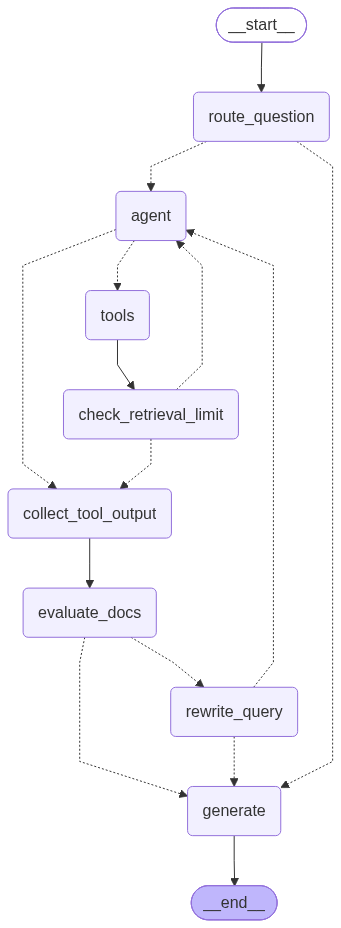

In [60]:
graph = graph_builder.compile()
graph

In [61]:
query_1 = (
    "According to the report, by how many million barrels per day could a 300-million EV fleet "
    "displace oil demand by 2030, and what does this mean relative to total global demand?"
)


result_1 = graph.invoke({
    "query": query_1,
    "messages": [],
    "retrieved_docs": [],
    "relevant_docs": [],
    "context": "",
    "retrieval_count": 0,
    "max_retrieval_step": 3,
    "rewrite_count": 0,
    "rewritten_query": "",
})

print("Is relevant:", result_1.get("is_relevant"))

inside else block
inside else block
inside else block
Is relevant: True


In [62]:
result_1

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 129, 'prompt_tokens': 461, 'total_tokens': 590, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EDPGS1lX92lpMZG6xdNZbNdgX6B9P', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a00966-327a-7f61-9168-341f527f1614-0', tool_calls=[{'name': 'vector_store_search', 'args': {'query': "300-million EV fleet displace oil demand by 2030 million barrels per day relative to total global demand 2030 report 'Will EVs Dampen the Oil Price Shock?'", 'k': 5}, 'id': 'call_22Fc7a9Fv4HnDhjn4dzJKeye', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_token

In [ ]:
# what is the average time it takes for individuals to fully dispose of their vehicles according to recent studies?'

In [64]:
query_2 = (
    "how long people take to get rid of their vehicles completely as per the report?"
)

result_2 = graph.invoke({
    "query": query_2,
    "messages": [],
    "retrieved_docs": [],
    "relevant_docs": [],
    "context": "",
    "retrieval_count": 0,
    "max_retrieval_step": 3,
    "rewrite_count": 0,
    "rewritten_query": "",
})


inside else block
inside else block
inside else block
inside if block


In [65]:
result_2

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 438, 'total_tokens': 561, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EDPIJWaeLlmFY503tBGWOatziVZTR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a00967-f72c-7872-9d8b-7128e70a88ec-0', tool_calls=[{'name': 'vector_store_search', 'args': {'query': "vehicle lifetime how long people take to get rid of their vehicles completely fleet turnover vehicle scrappage 'Will EVs Dampen the Oil Price Shock?'", 'k': 5}, 'id': 'call_bMirZLabpHVrwWg3xlrP2Hzp', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 43